#### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import os
import argparse
np.set_printoptions(precision=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#### Util Functions

In [2]:
def set_npseed(seed):
	np.random.seed(seed)


def set_torchseed(seed):
	torch.manual_seed(seed)
	torch.cuda.manual_seed(seed)
	torch.cuda.manual_seed_all(seed)
	torch.backends.cudnn.deterministic = True
	torch.backends.cudnn.benchmark = False

def choose(a,c):
	return np.array([c[a[I]][I] for I in np.ndindex(a.shape)])


In [3]:
def return_output_vals(DLGN_obj, train_data_curr, train_labels_curr, device=device):
    train_outputs_values, train_outputs_gate_scores =DLGN_obj(torch.Tensor(train_data_curr).to(device))
    train_preds = train_outputs_values[-1]
    return train_preds.cpu().detach().numpy()

def give_loss(DLGN_obj, data_curr, labels_curr, device=device):
    outputs_values, outputs_gate_scores =DLGN_obj(torch.Tensor(data_curr).to(device))
    preds = outputs_values[-1]
    criterion = nn.CrossEntropyLoss()
    outputs = torch.cat((-1*preds,preds), dim=1)
    targets = torch.tensor(labels_curr, dtype=torch.int64).to(device)
    loss = criterion(outputs, targets)
    return loss.cpu().detach().numpy()

def give_error(DLGN_obj, data_curr, labels_curr, device=device):
    outputs_values, outputs_gate_scores =DLGN_obj(torch.Tensor(data_curr).to(device))
    preds = outputs_values[-1]
    preds = preds.detach().cpu().numpy()
    error=np.sum(labels_curr != (np.sign(preds[:,0])+1)//2 )
    return error


#### Generate ODT Dataset

In [4]:
def parent(i):
    if i==0:
        return -1
    else:
        return (i-1)//2


def level(i):
    ans= []
    for el in i:
        ans.append(int(np.log2(el+1)))
    return np.array(ans)

def checkPresent(DLGN_neurons_list,path):
    set_list =[]
    for i in range(len(DLGN_neurons_list)):
        set_list.append(set(DLGN_neurons_list[i]).intersection(set(path)))
    return set_list


In [5]:
def data_gen_decision_tree(num_data=1000, dim=2, seed=0, w_list=None, b_list=None, 
							vals=None, num_levels=2):
	set_npseed(seed=seed)
	# Construct a complete decision tree with 2**num_levels-1 internal nodes, 
	# e.g. num_levels=2 means there are 3 internal nodes.
	# w_list, b_list is a list of size equal to num_internal_nodes
	# vals is a list of size equal to num_leaf_nodes, with values +1 or -1
	num_internal_nodes = 2**num_levels - 1
	num_leaf_nodes = 2**num_levels
	stats = np.zeros(num_internal_nodes+num_leaf_nodes)

	if vals is None:
		vals = np.arange(0,num_internal_nodes+num_leaf_nodes,1,dtype=np.int32)%2
		vals[:num_internal_nodes] = -99

	if w_list is None:
		w_list = np.random.standard_normal((num_internal_nodes, dim))
		w_list = w_list/np.linalg.norm(w_list, axis=1)[:, None]
		b_list = np.zeros((num_internal_nodes))
		Q,R = np.linalg.qr(w_list.T)
		w_list = Q.T

	data_x = np.random.standard_normal((num_data, dim))
	data_x /= np.sqrt(np.sum(data_x**2, axis=1, keepdims=True))
	relevant_stats = data_x @ w_list.T + b_list
	

	curr_index = np.zeros(shape=(num_data), dtype=int)
	
	for level in range(num_levels):
		nodes_curr_level=list(range(2**level - 1,2**(level+1)-1  ))
		for el in nodes_curr_level:
			relevant_stats[:,el] += b_list[el]
		decision_variable = choose(curr_index, relevant_stats.T) 
		# Go down and right if wx+b>0 down and left otherwise. 
		# i.e. 0 -> 1 if w[0]x+b[0]<0 and 0->2 otherwise
		curr_index = (curr_index+1)*2 - (1-(decision_variable > 0))

	bound_dist = np.min(np.abs(relevant_stats), axis=1)
	# thres = 0.02
	thres =0.0
	labels = vals[curr_index]
	data_x_pruned = data_x[bound_dist>thres]
	labels_pruned = labels[bound_dist>thres]
	relevant_stats = np.sign(data_x_pruned @ w_list.T + b_list)
	nodes_active = np.zeros((len(data_x_pruned),  num_internal_nodes+num_leaf_nodes), dtype=np.int32)
	for node in range(num_internal_nodes+num_leaf_nodes):
		if node==0:
			stats[node]=len(relevant_stats)
			nodes_active[:,0]=1
			continue
		parent = (node-1)//2
		nodes_active[:,node]=nodes_active[:,parent]
		right_child = node-(parent*2)-1 # 0 means left, 1 means right 1 has children 3,4
		if right_child==1:
			nodes_active[:,node] *= relevant_stats[:,parent]>0
		if right_child==0:
			nodes_active[:,node] *= relevant_stats[:,parent]<0		
		stats = nodes_active.sum(axis=0)
	return ((data_x_pruned, labels_pruned), (w_list, b_list, vals), stats)


num_data = 160000
input_dim=100
seeds = np.random.random_integers(0,10000,100)
seeds=[1387]
for seed in seeds:
	((data_x, labels), (w_list, b_list, vals), stats) = data_gen_decision_tree(
												dim=input_dim, seed=seed, num_levels=5,
												num_data=num_data)
	seed_set=seed

num_data = len(data_x)


w_list_old = np.array(w_list)
b_list_old = np.array(b_list)

print(data_x.shape)
print(labels.shape)

num_data = len(data_x)
num_train= num_data//2
num_vali = num_data//4
num_test = num_data//4
train_data = data_x[:num_train,:]
train_data_labels = labels[:num_train]

vali_data = data_x[num_train:num_train+num_vali,:]
vali_data_labels = labels[num_train:num_train+num_vali]

test_data = data_x[num_train+num_vali :,:]
test_data_labels = labels[num_train+num_vali :]

/tmp/ipykernel_2531868/1357979084.py:65: DeprecationWarning: This function is deprecated. Please call randint(0, 10000 + 1) instead
  seeds = np.random.random_integers(0,10000,100)


(160000, 100)
(160000,)


#### Hyper Parameters

In [6]:
class Args:
    def __init__(self):
        self.numlayer=5
        self.numnodes=16
        self.beta=11.
        self.lr = 0.003
        self.hc = 0
        self.di = 0
        self.reg = 2e-4

In [7]:
args =  Args()

num_layer = args.numlayer
num_neuron = args.numnodes
beta = args.beta
lr=args.lr
reg = args.reg
saved_epochs = [0,1,2,3,4,5,6,7,8,9]+list(range(10,301,10))
no_of_batches=500
num_hidden_nodes=[num_neuron]*num_layer

#### DLGN Class

In [8]:
class DLGN_FC(nn.Module):
	def __init__(self, input_dim=None, output_dim=None, num_hidden_nodes=[], beta=30, mode='pwc', device=device):		
		super(DLGN_FC, self).__init__()
		self.num_hidden_layers = len(num_hidden_nodes)
		self.beta=beta  # Soft gating parameter
		self.mode = mode
		self.num_nodes=[input_dim]+num_hidden_nodes+[output_dim]
		self.gating_layers=nn.ModuleList()
		self.value_layers=nn.ModuleList()
		
		for i in range(self.num_hidden_layers+1):
			if i!=self.num_hidden_layers:
				temp = nn.Linear(self.num_nodes[0], self.num_nodes[i+1], bias=False)
				self.gating_layers.append(temp)
			temp = nn.Linear(self.num_nodes[i], self.num_nodes[i+1], bias=False)
			self.value_layers.append(temp)


	def set_parameters_with_mask(self, to_copy, parameter_masks):
	
		for (name, copy_param) in to_copy.named_parameters():
			copy_param = copy_param.clone().detach()
			orig_param  = self.state_dict()[name]
			if name in parameter_masks:
				param_mask = parameter_masks[name]>0
				orig_param[param_mask] = copy_param[param_mask]
			else:
				orig_param = copy_param.data.detach()
	

								

	def return_gating_functions(self):
		effective_weights = []
		for i in range(self.num_hidden_layers):
			curr_weight = self.gating_layers[i].weight.detach().clone()
			effective_weights.append(curr_weight)
		return effective_weights
		# effective_weights (and effective biases) is a list of size num_hidden_layers
							

	def forward(self, x):
		gate_scores=[x]
		if self.mode=='pwc':
			values=[torch.ones(x.shape).to(device)]
		else:
			values=[x]
		
		for i in range(self.num_hidden_layers):
			gate_scores.append( (x@self.gating_layers[i].weight.T) )
			curr_gate_on_off = torch.sigmoid(self.beta * gate_scores[-1])
			values.append(self.value_layers[i](values[-1])*curr_gate_on_off)
		values.append(self.value_layers[self.num_hidden_layers](values[-1]))
		# Values is a list of size 1+num_hidden_layers+1
		#gate_scores is a list of size 1+num_hidden_layers
		return values,gate_scores

#### Train

In [ ]:
def regulariser(DLGN_obj):
    ans= 0
    for l in range(DLGN_obj.num_hidden_layers):
        ans+= ( (DLGN_obj.gating_layers[l].weight.abs()) ** 2 ).sum()
    return ans

In [ ]:
def train_dlgn (DLGN_obj, train_data_curr,vali_data_curr,test_data_curr,
				train_labels_curr,test_labels_curr,vali_labels_curr,
				parameter_mask=dict(), reg_coeff = 0.0, device=device):
	DLGN_obj = DLGN_obj.to(device)

	criterion = nn.CrossEntropyLoss()
	# optimizer = optim.SGD(DLGN_obj.parameters(), lr=lr, momentum=0.0)
	optimizer = optim.AdamW(DLGN_obj.parameters(), lr=lr, weight_decay=0.)


	train_data_torch = torch.Tensor(train_data_curr)
	vali_data_torch = torch.Tensor(vali_data_curr)
	test_data_torch = torch.Tensor(test_data_curr)

	train_labels_torch = torch.tensor(train_labels_curr, dtype=torch.int64)
	test_labels_torch = torch.tensor(test_labels_curr, dtype=torch.int64)
	vali_labels_torch = torch.tensor(vali_labels_curr, dtype=torch.int64)

	num_batches = no_of_batches
	batch_size = len(train_data_curr)//num_batches
	losses=[]
	DLGN_obj_store = []
	best_vali_error = len(vali_labels_curr)
	
	debug_models= []
	train_losses = []
	running_loss = 0.7*num_batches # initial random loss = 0.7 
	for epoch in tqdm(range(saved_epochs[-1]+1)):  # loop over the dataset multiple times
		if epoch in saved_epochs:
			DLGN_obj_store.append(deepcopy(DLGN_obj).to(torch.device('cpu')))
			train_outputs_values, train_outputs_gate_scores =DLGN_obj(torch.Tensor(train_data_curr).to(device))
			train_preds = train_outputs_values[-1]
			criterion = nn.CrossEntropyLoss()
			outputs = torch.cat((-1*train_preds,train_preds), dim=1)
			targets = torch.tensor(train_labels_curr, dtype=torch.int64).to(device)
			train_loss = criterion(outputs, targets)
			
			train_losses.append(train_loss.detach())

			print("Train loss = ",train_loss)
			test_outputs_values, test_outputs_gate_scores =DLGN_obj(torch.Tensor(test_data_curr).to(device))
			test_preds = test_outputs_values[-1]
			test_preds = test_preds.detach().cpu().numpy()
			print("Test error=",np.sum(test_labels_curr != (np.sign(test_preds[:,0])+1)//2 ))

			if train_loss < 5e-4:
				break
			if np.isnan(train_loss.detach().cpu().numpy()):
				break
		running_loss = 0.0
		for batch_start in range(0,len(train_data_curr),batch_size):
			if (batch_start+batch_size)>len(train_data_curr):
				break
			optimizer.zero_grad()
			inputs = train_data_torch[batch_start:batch_start+batch_size]
			targets = train_labels_torch[batch_start:batch_start+batch_size].reshape(batch_size)
			inputs = inputs.to(device)
			targets = targets.to(device)
			values,gate_scores = DLGN_obj(inputs)
			outputs = torch.cat((-1*values[-1], values[-1]), dim=1)
			loss = criterion(outputs, targets)
			value_regul	= regulariser(DLGN_obj)
			regularised_loss = loss + reg_coeff * value_regul		
			regularised_loss.backward()
			
			for name,param in DLGN_obj.named_parameters():
				parameter_mask[name] = parameter_mask[name].to(device)
				param.grad *= parameter_mask[name]   
	
			optimizer.step()
			running_loss += loss.item()


		train_outputs_values, train_outputs_gate_scores =DLGN_obj(torch.Tensor(train_data_curr).to(device))
		train_preds = train_outputs_values[-1]
		criterion = nn.CrossEntropyLoss()
		outputs = torch.cat((-1*train_preds,train_preds), dim=1)
		targets = torch.tensor(train_labels_curr, dtype=torch.int64).to(device)
		train_loss = criterion(outputs, targets)
    
		losses.append(train_loss.cpu().detach().clone().numpy())
		inputs = vali_data_torch.to(device)
		targets = vali_labels_torch.to(device)
		values,gate_scores =DLGN_obj(inputs)
		vali_preds = torch.cat((-1*values[-1], values[-1]), dim=1)
		vali_preds = torch.argmax(vali_preds, dim=1)
		vali_error= torch.sum(targets!=vali_preds)
		if vali_error < best_vali_error:
			DLGN_obj_return = deepcopy(DLGN_obj)
			best_vali_error = vali_error
	plt.figure()
	plt.title("DLGN loss vs epoch")
	plt.plot(losses)
	DLGN_obj_return.to(torch.device('cpu'))
	return train_losses, DLGN_obj_return, DLGN_obj_store, losses, debug_models

In [ ]:
set_torchseed(1234)
DLGN_init= DLGN_FC(input_dim=input_dim, output_dim=1, num_hidden_nodes=num_hidden_nodes, beta=beta)


In [ ]:
for name,parameter in DLGN_init.named_parameters():
    print(name)
    print(parameter.shape)
print(train_data.shape)

train_parameter_masks=dict()
for name,parameter in DLGN_init.named_parameters():
    if "val" in name:
        train_parameter_masks[name]=torch.ones_like(parameter)  # Updating all value network layers
    if "gat" in name:
        train_parameter_masks[name]=torch.ones_like(parameter)
        
    train_parameter_masks[name].to(device)

saved_epochs = [0,1,2,3,4,5,6,7,8,9]+list(range(10,301,10)) + list(range(301, 1101, 100))

In [ ]:
set_torchseed(5000)
train_losses, DLGN_obj_final, DLGN_obj_store, losses , debug_models= train_dlgn(train_data_curr=train_data,
                                            vali_data_curr=vali_data,
                                            test_data_curr=test_data,
                                            train_labels_curr=train_data_labels,
                                            vali_labels_curr=vali_data_labels,
                                            test_labels_curr=test_data_labels,
                                            DLGN_obj=deepcopy(DLGN_init),
                                            parameter_mask=train_parameter_masks,
                                            reg_coeff = reg, # 0 or 2e-4
                                            device=device
                                            )


torch.cuda.empty_cache() 
losses=np.array(losses)

In [ ]:
len(DLGN_obj_store)

In [ ]:
set_torchseed(6675)
DLGN_init= DLGN_FC(input_dim=input_dim, output_dim=1, num_hidden_nodes=num_hidden_nodes, beta=beta)


DLGN_init =  deepcopy(DLGN_obj_store[-1])
ew = DLGN_init.return_gating_functions()

train_parameter_masks=dict()
for name,parameter in DLGN_init.named_parameters():
    if "val" in name:
        train_parameter_masks[name]=torch.ones_like(parameter) # Updating all value network layers
    if "gat" in name:
        train_parameter_masks[name]=torch.ones_like(parameter)
    train_parameter_masks[name].to(device)


for l in range(num_layer):
    norms = ew[l].norm(dim=1)
    sorted_norms, indices = torch.sort(norms, descending=True)
    a = DLGN_init.gating_layers[l].weight.detach()        
    b = DLGN_init.value_layers[l].weight.detach()
    c = DLGN_init.value_layers[l+1].weight.detach()  
    # a *= 10.
    # b /= 2.
    # c /= 2.
    name = "gating_layers."+str(l)+".weight"     
    name2 = "value_layers."+str(l)+".weight" 
    name3 = "value_layers."+str(l+1)+".weight"     
    for k in range(num_neuron):
        if ew[l][k].norm() > 2:
            # print("Active neuron at ",l,k)
            a[k,:] *= 1.
            continue
        elif ew[l][k].norm() > sorted_norms[-1]-0.1:       
            # print("Bypass neuron at ",l,k)     
            a[k,:] *= 0.
            train_parameter_masks[name][k,:]*=0.
        else:
            # print("Dead neuron at ",l,k)     
            a[k,:] *= 0.
            b[k,:] *= 0.
            c[:,k] *= 0.
            train_parameter_masks[name][k,:]*=0.
            train_parameter_masks[name2][k,:]*=0.
            train_parameter_masks[name3][:,k]*=0.
            continue

ew = DLGN_init.return_gating_functions()


In [ ]:
saved_epochs = [0,1,2,3,4,5,6,7,8,9]+list(range(10,301,10))
train_losses, DLGN_obj_final, DLGN_obj_store_2, losses , debug_models= train_dlgn(train_data_curr=train_data,
                                            vali_data_curr=vali_data,
                                            test_data_curr=test_data,
                                            train_labels_curr=train_data_labels,
                                            vali_labels_curr=vali_data_labels,
                                            test_labels_curr=test_data_labels,
                                            DLGN_obj=deepcopy(DLGN_init),
                                            parameter_mask=train_parameter_masks,
                                            reg_coeff = 0
                                            )


torch.cuda.empty_cache() 
losses=np.array(losses)


#### Visualize

In [10]:
model_list1 = DLGN_obj_store
model_list2 = DLGN_obj_store_2

40000


  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:03<00:00, 12.18it/s]


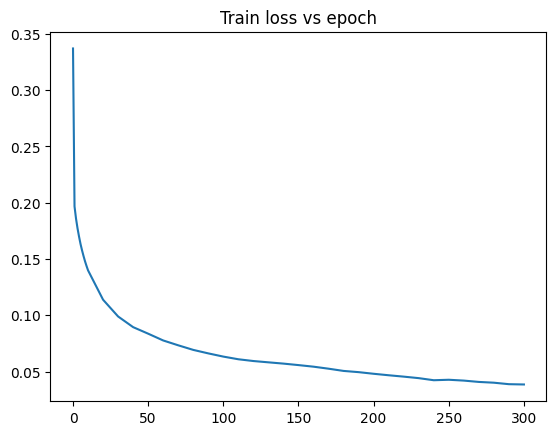

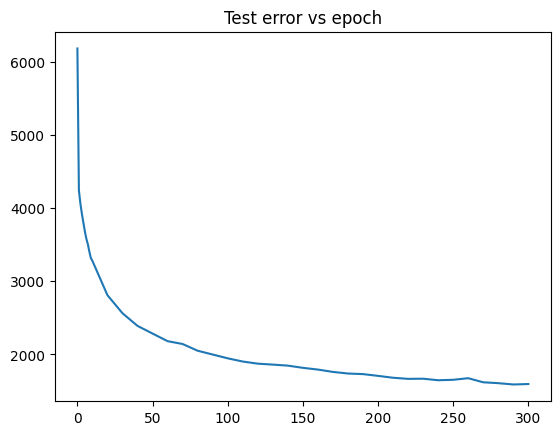

In [25]:
print(len(test_data_labels))
model_list = model_list2

train_losses = []
test_errors = []
for i in tqdm(range(len(model_list))):
    train_losses.append(give_loss(model_list[i].to(device), train_data, train_data_labels))
    test_errors.append(give_error(model_list[i].to(device), test_data, test_data_labels) )

plt.figure()
plt.plot(saved_epochs[:len(train_losses)],train_losses);
plt.title("Train loss vs epoch");
plt.figure()
plt.plot(saved_epochs[:len(train_losses)],test_errors);
plt.title("Test error vs epoch");

40000


100%|██████████| 40/40 [00:03<00:00, 11.67it/s]


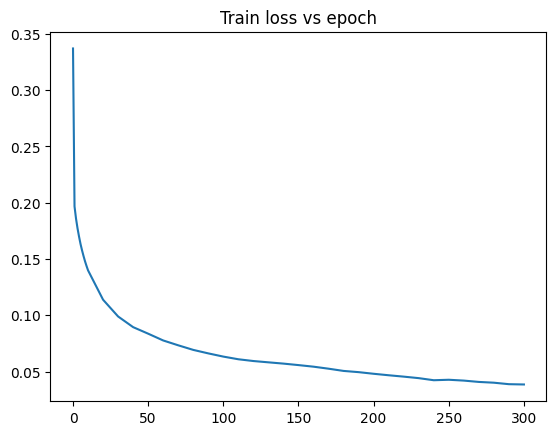

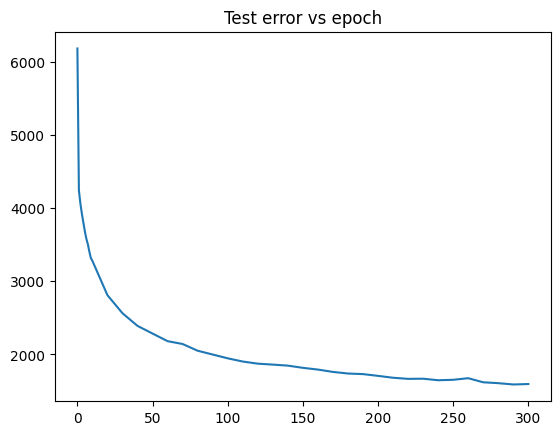

In [12]:
print(len(test_data_labels))
model_list = model_list2

train_losses = []
test_errors = []
for i in tqdm(range(len(model_list))):
    train_losses.append(give_loss(model_list[i].to(device), train_data, train_data_labels))
    test_errors.append(give_error(model_list[i].to(device), test_data, test_data_labels) )

plt.figure()
plt.plot(saved_epochs[:len(train_losses)],train_losses);
plt.title("Train loss vs epoch");
plt.figure()
plt.plot(saved_epochs[:len(train_losses)],test_errors);
plt.title("Test error vs epoch");

In [19]:
model_list = model_list1

ew_store = np.zeros((len(model_list),num_layer,num_neuron,input_dim))
for i,model in enumerate(model_list):
    ew = model_list[i].return_gating_functions()
    ew_store[i,0] = ew[0].cpu().numpy()
    ew_store[i,1] = ew[1].cpu().numpy()
    ew_store[i,2] = ew[2].cpu().numpy()
    ew_store[i,3] = ew[3].cpu().numpy()
    ew_store[i,4] = ew[4].cpu().numpy()  

In [20]:
len(ew_store)

48

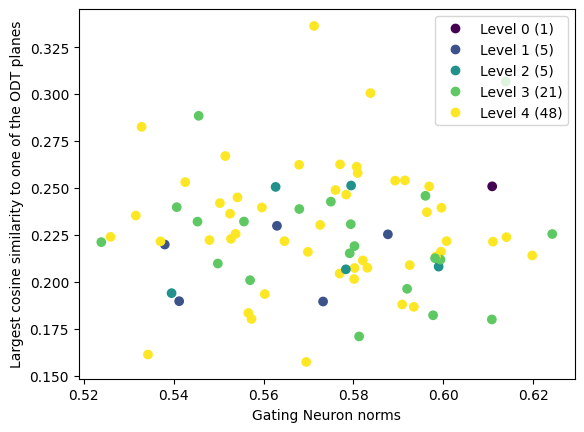

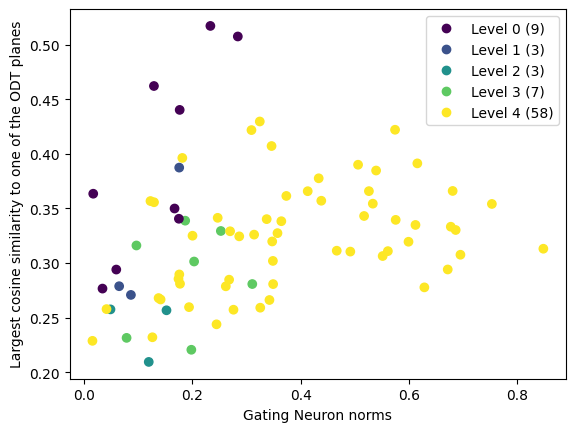

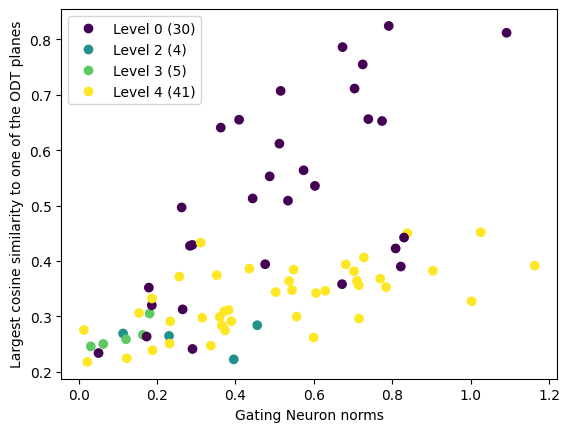

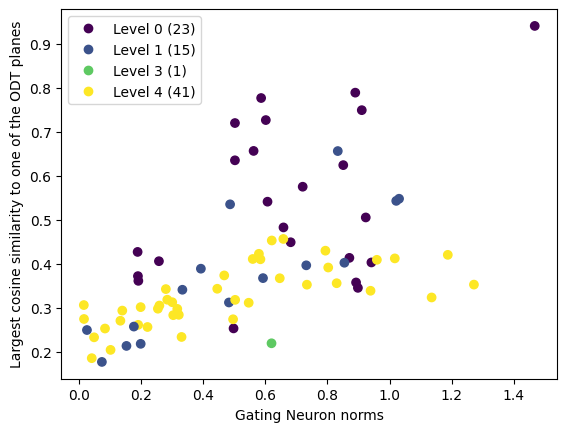

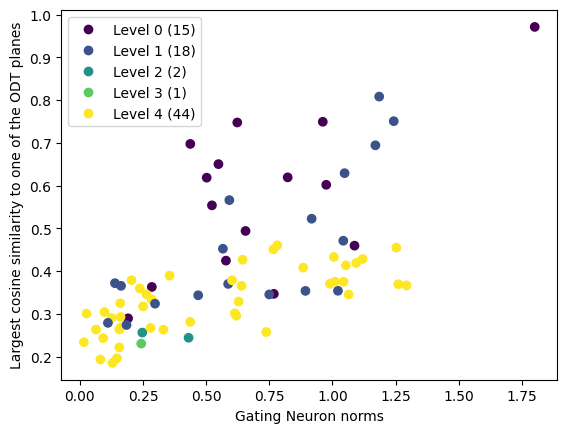

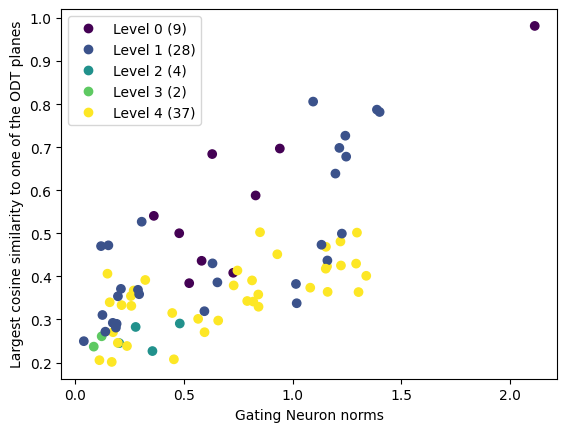

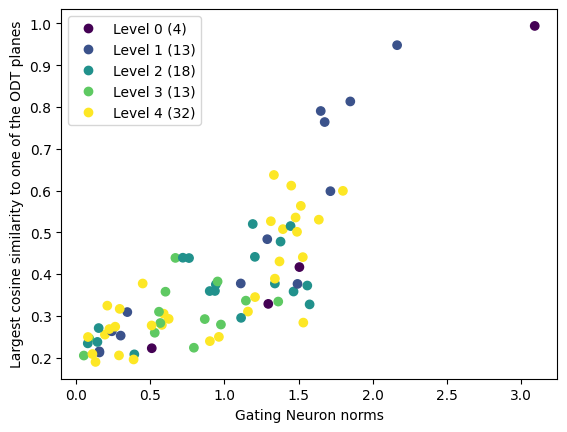

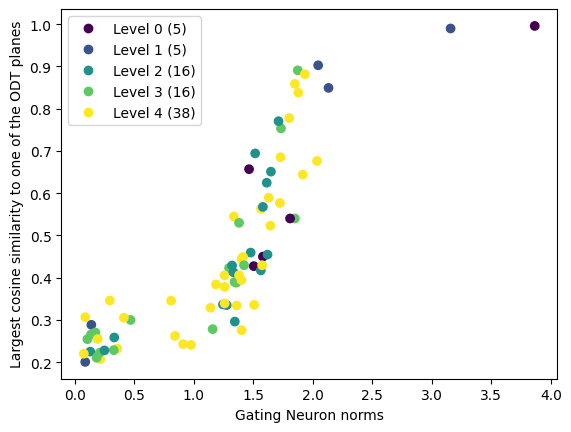

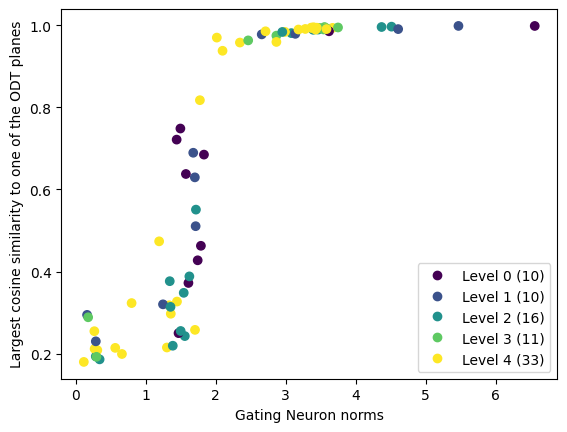

In [22]:
import re
np.set_printoptions(precision=1)

for epoch_index in [0,1,2,3,4,5,10,11,-1]:
# for epoch_index in [-1]:
    a = np.sqrt((ew_store[epoch_index]**2).sum(axis=2))
    b = np.max(np.abs((ew_store[epoch_index]@w_list.T)), axis=2)
    c = np.argmax(np.abs((ew_store[epoch_index]@w_list.T)), axis=2)
    c_serial=c.reshape(-1)
    x= a.reshape(-1)
    y = (b/a).reshape(-1)
    x= x[~np.isnan(y)]
    c_serial= c_serial[~np.isnan(y)]
    y = y[~np.isnan(y)]
    names=[]
    for l in range(num_layer):
        for k in range(num_neuron):
            names.append(str((c[l,k])))
    
    xlabel="Gating Neuron norms"
    ylabel="Largest cosine similarity to one of the ODT planes"
    # title = "Epoch "+str(saved_epochs[epoch_index])
    plt.figure()
    scatter = plt.scatter(x,y,c=level(c_serial), vmin=0, vmax=num_layer-1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # plt.title(title)
    legend_text = scatter.legend_elements()[1] 
    for i in range(len(legend_text)):
        el = legend_text[i]
        num =  int(re.findall(r'\d+', el)[0])
        count = np.sum(level(c_serial)==num)
        legend_text[i] = "Level "+str(num)+" ("+str(count)+")"

    plt.legend(scatter.legend_elements()[0],legend_text)
    # plt.savefig("figures/multi_path_reg_2e-4.pdf",
    #         format="pdf",
    #         bbox_inches="tight")
plt.show()